# Fourier Transforms Exercises

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib

%matplotlib inline
matplotlib.rcParams.update({'font.size': 16,'figure.figsize':(10,6)})

## Discrete Fourier Transform (DFT)

$$S[m] = \sum_{n=0}^{N-1} s[n] e^{-i 2 \pi m \left({\frac{n}{N}}\right) }$$

Write a function that computes the DFT of a 1D arraay.

In [34]:
def DFT_slow(s):
    """
    Compute the discrete Fourier Transform of the 1D array x
    :param s: (array)
    """
    N = len(s)
    S = np.zeros(N, dtype=complex)
    for m in range(N):
        for n in range(N):
            S[m] += s[n] * np.exp(-2j * np.pi * m * n / N)
    return S

If you have extra time try writing a function that also computes the DFT but by using the dot product (recall the dot product sums over the element-wise products).

In [35]:
def DFT(s):
    """
    Compute the discrete Fourier Transform of the 1D array x using dot product
    :param s: (array)
    """
    N = len(s)
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, s)

Below is an example signal constructed to test out both your DFT functions

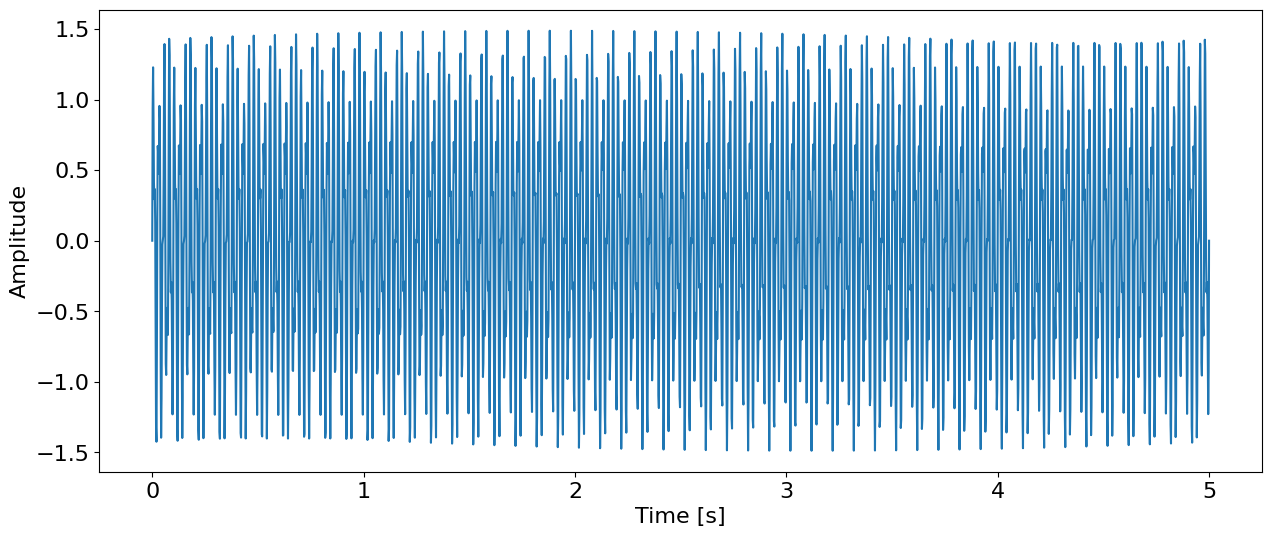

In [36]:
num_sec = 5         # sampling period (in seconds)
num_pts = 500       # samples per second


# make a complex signal with two sinusoids to test both of your DFT calculation methods
t = np.linspace(0, num_sec, num_pts*num_sec)
s = np.sin(40 * 2 * np.pi * t) + 0.5 * np.sin(90 * 2 * np.pi * t)

plt.figure(figsize=(15,6))
plt.ylabel("Amplitude")
plt.xlabel("Time [s]")
plt.plot(t, s)
plt.show()

In [37]:
Fs = 1/(t[1] - t[0])     # sample rate
N = s.size               # number of samples (length of signal)

k = np.arange(N)         # frequncy bins
T = N/Fs                 # frequency interval of a single bin
frq = k/T                # two sides frequency range
frq = frq[range(N//2)]   # one side frequency range (Fourier transform outputs symmetric frequencies)

### Perform Fourier Transform on the signal defined above using both of your DFT functions and numpy's fft

Perform a DFT on the example signal created above. As a bonus, time how long it takes for each method to run and compare them! (You can use the time module, i.e. "import time".)

In [38]:
import time

# DFT_slow
start_time = time.time()
dft_slow_result = DFT_slow(s)
end_time = time.time()
print(f"DFT_slow execution time: {end_time - start_time:.6f} seconds")

# DFT(s)
start_time = time.time()
dft_result = DFT(s)
end_time = time.time()
print(f"DFT execution time (dot product): {end_time - start_time:.6f} seconds")

# numpy FFT
start_time = time.time()
numpy_fft_result = np.fft.fft(s)
end_time = time.time()
print(f"Numpy FFT execution time: {end_time - start_time:.6f} seconds")

print("\nComparing results (first 5 elements):")
print(f"DFT_slow: {dft_slow_result[:5]}")
print(f"DFT: {dft_result[:5]}")
print(f"Numpy FFT: {numpy_fft_result[:5]}")

DFT_slow execution time: 13.910657 seconds
DFT execution time (dot product): 0.345880 seconds
Numpy FFT execution time: 0.000303 seconds

Comparing results (first 5 elements):
DFT_slow: [9.31187993e-13+0.j         7.39146288e-06-0.00588194j
 2.95677681e-05-0.01176462j 6.65346717e-05-0.01764879j
 1.18301772e-04-0.02353519j]
DFT: [9.38138456e-13+0.j         7.39146287e-06-0.00588194j
 2.95677681e-05-0.01176462j 6.65346717e-05-0.01764879j
 1.18301772e-04-0.02353519j]
Numpy FFT: [9.13047415e-13+0.j         7.39146287e-06-0.00588194j
 2.95677681e-05-0.01176462j 6.65346717e-05-0.01764879j
 1.18301772e-04-0.02353519j]


## Plot the Frequency Spectrum

Plot the frequency spectrum from using your DFT function(s) and numpy's fft. They should all come out the same.

Note that when we plot a DFT we take the absolute value of the value returned from the fft. (The raw value returned by the fft has both real and imaginary components. When we take its absolute value we are calculating the magnitude of the sine waves that make up the original signal and ignoring their phases.) Also, we often only plot the first half of the fft. This is because when we take the fft of a completely real signal, the second half of the fft is just the complex conjugate of the first half, and thus redundant.

In [39]:
def plot_FT(ft, T, N, flipxy=False):
    """
    plot the Fourier Transform frequency spectrum
    :param ft: output of Fourier Transform (i.e., np.fft.fft())
    :param T: sample resolution (in seconds)
    :param N: total number of samples

    Note: only plot the first 1/2 of what the FT returns
    (the other half is just the complex congugate)

    """

    f = np.linspace(0.0, 1.0/(2.0*T), N//2)

    # only 1/2
    ft_magnitude = 2.0/N * np.abs(ft[0:N//2])

    plt.figure(figsize=(15,6))
    if not flipxy:
        plt.plot(f, ft_magnitude)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
    else:
        # sometimes we may want to plot on flipped x/y axis
        plt.plot(ft_magnitude, f)
        plt.ylabel("Frequency (Hz)")
        plt.xlabel("Magnitude")
    plt.grid()
    plt.show()

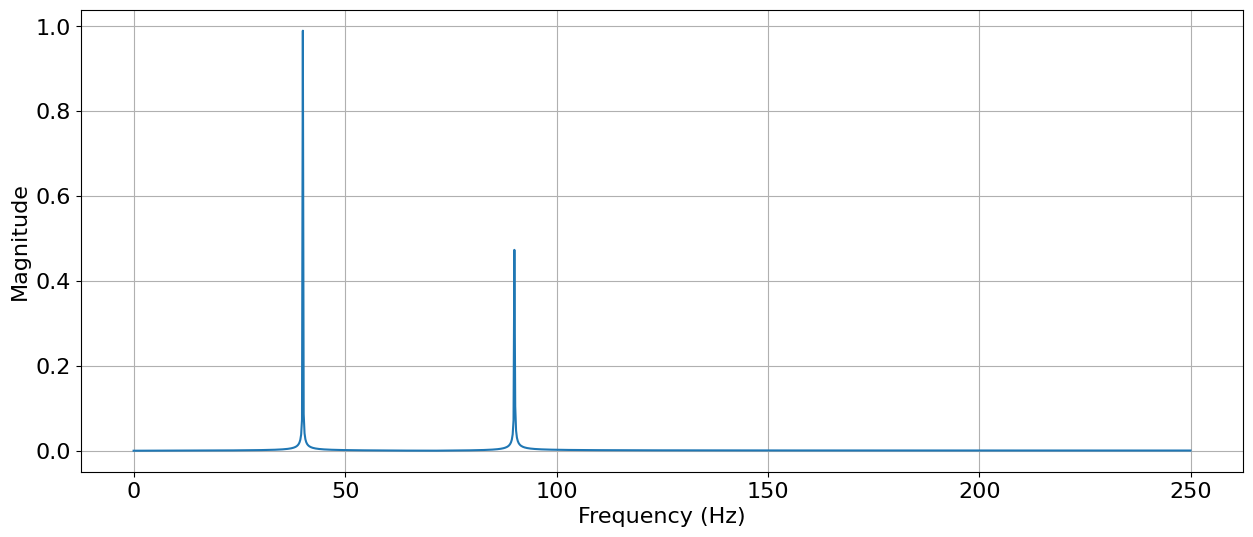

In [40]:
# plot using the above function you just defined and np.fft.fft to ensure they provide the same answer

T = t[1] - t[0]  # sample rate
N = len(s)

plot_FT(numpy_fft_result, T, N)


## Inverse Fourier Transform (IFT)

Let's try a more complicated signal.

Try taking the FFT of the ecg signal (you can use np.fft.fft) and plot it next to the time-domain signal. Can you identify any peaks in the fft corresponding to repeating structures in the ecg? (You might need to zoom into the x-axis.)

Also, use the ifft function (np.fft.ifft) to reproduce the time-domain signal again from the fft and verify it matches the original.

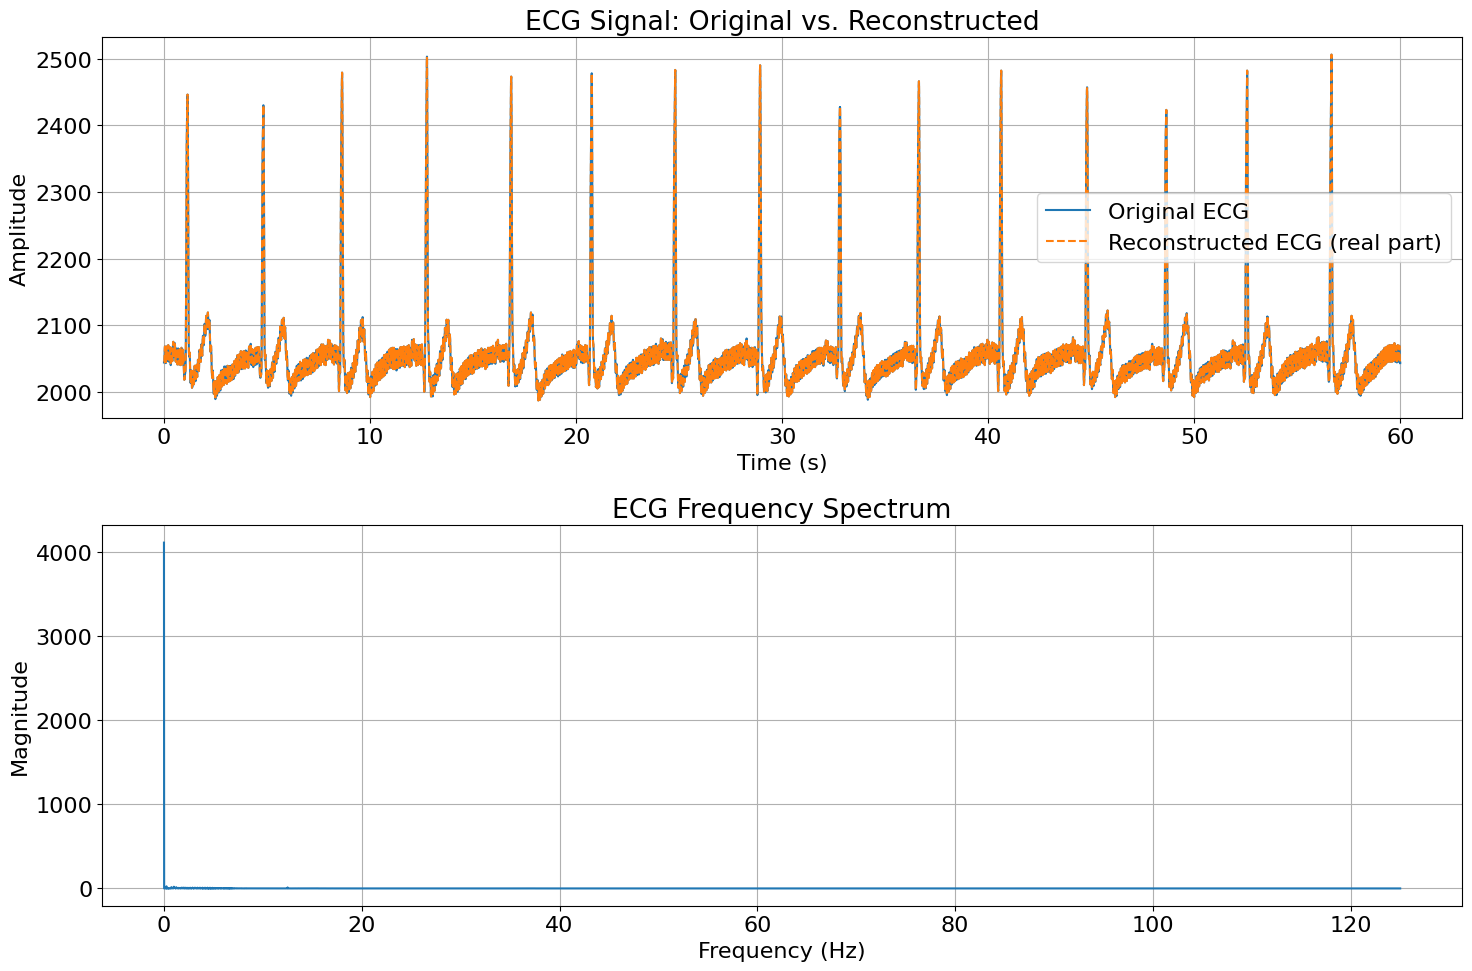

In [41]:
y_ecg = np.loadtxt('https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week2/ecg.txt',skiprows=4)

# 250 hz used (subject to change - just a random val)
Fs_ecg = 250  # Hz
T_ecg = 1 / Fs_ecg # sample resolution in seconds
N_ecg = len(y_ecg) # total number of samples

## FFT and IFFT
fft_ecg = np.fft.fft(y_ecg)
y_ecg_recon = np.fft.ifft(fft_ecg)

# plot time-domain signals and frequency spectrum
plt.figure(figsize=(15, 10))

# plot original and reconstructed time-domain signal
ax1 = plt.subplot(2, 1, 1)
time_ecg = np.arange(N_ecg) * T_ecg
ax1.plot(time_ecg, y_ecg, label='Original ECG')
ax1.plot(time_ecg, y_ecg_recon.real, '--', label='Reconstructed ECG (real part)')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_title("ECG Signal: Original vs. Reconstructed")
ax1.legend()
ax1.grid()

# plot frequency spectrum
ax2 = plt.subplot(2, 1, 2)
# calculate frequency array for the spectrum
f_ecg = np.linspace(0.0, 1.0/(2.0*T_ecg), N_ecg//2)
# plot only the first half of the spectrum magnitude
ft_magnitude_ecg = 2.0/N_ecg * np.abs(fft_ecg[0:N_ecg//2])
ax2.plot(f_ecg, ft_magnitude_ecg)
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.set_title("ECG Frequency Spectrum")
ax2.grid()

plt.tight_layout()
plt.show()

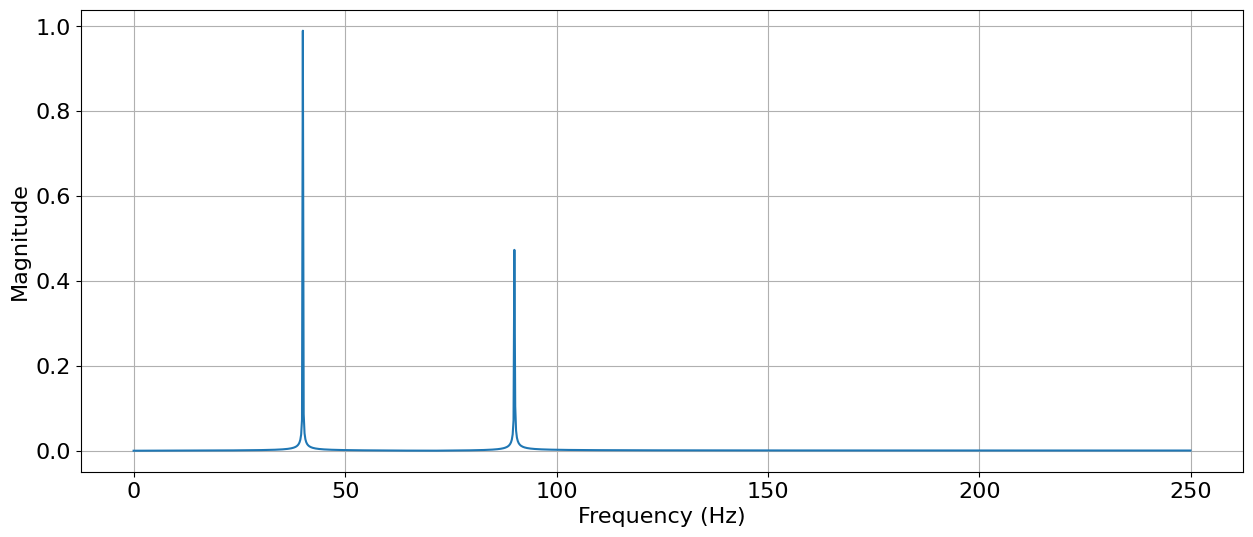

In [42]:
T = t[1]-t[0]
N = t.size

## PLOT FREQUENCY SPECTRUM
plot_FT(numpy_fft_result, T, N)

Okay, well that looks pretty good, but how well were we able to reconstruct the signal really? Check the correlation coefficient.

In [43]:
np.corrcoef(abs(y_ecg), abs(y_ecg_recon))

array([[1., 1.],
       [1., 1.]])

## Okay, but that was a relatively periodic signal...
Let's try with a signal that doesn't look periodic at all!

(i.e. compare the raw signal to its fft, and reconstruct the raw signal by performing an inverse Fourier transform)

In [44]:
import scipy.io.wavfile
from IPython.display import Audio
import os
import numpy as np

wav_file_path = "./sounds/newt.wav"

# Read the validated wav file (original code was not working - used AI to fix this up and get it working)
try:
    sample_rate, y_newt = scipy.io.wavfile.read(wav_file_path)
    t_newt = np.linspace(0, len(y_newt) / sample_rate, len(y_newt))

    print(f'Sample rate: {sample_rate} Hz')
    print(f'Signal length: {len(y_newt)} samples')
except Exception as e:
    print(f"Error reading wav file: {e}")

Sample rate: 11025 Hz
Signal length: 99808 samples


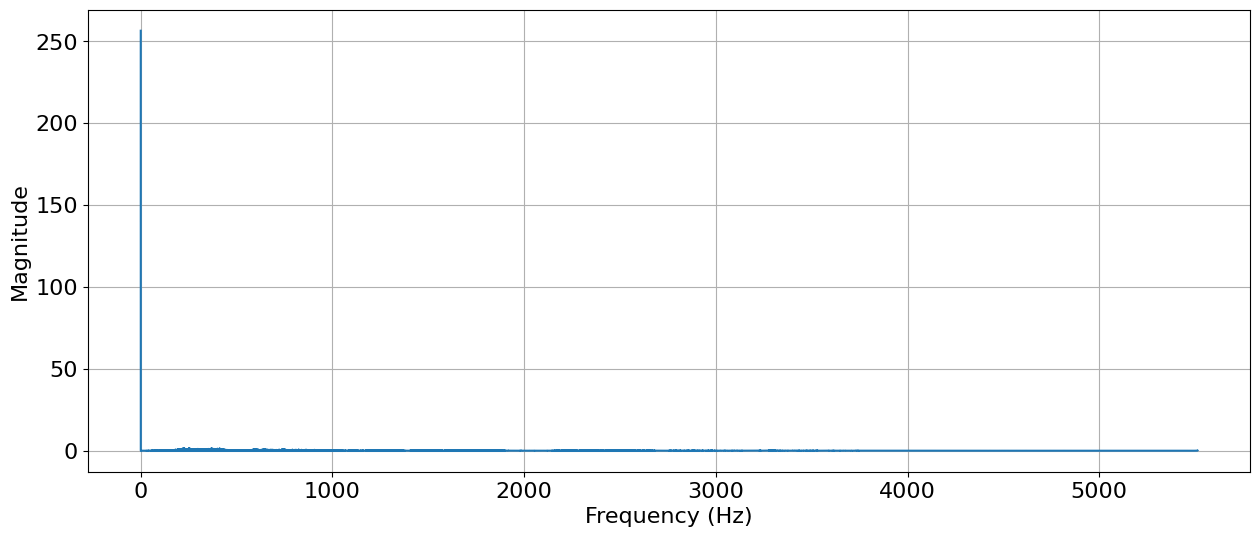

In [45]:
## PLOT FREQUENCY SPECTRUM

T_audio = 1 / sample_rate
N_audio = len(y_newt)

# fft
y_newt_fft = np.fft.fft(y_newt)

# plot
plot_FT(y_newt_fft, T_audio, N_audio)

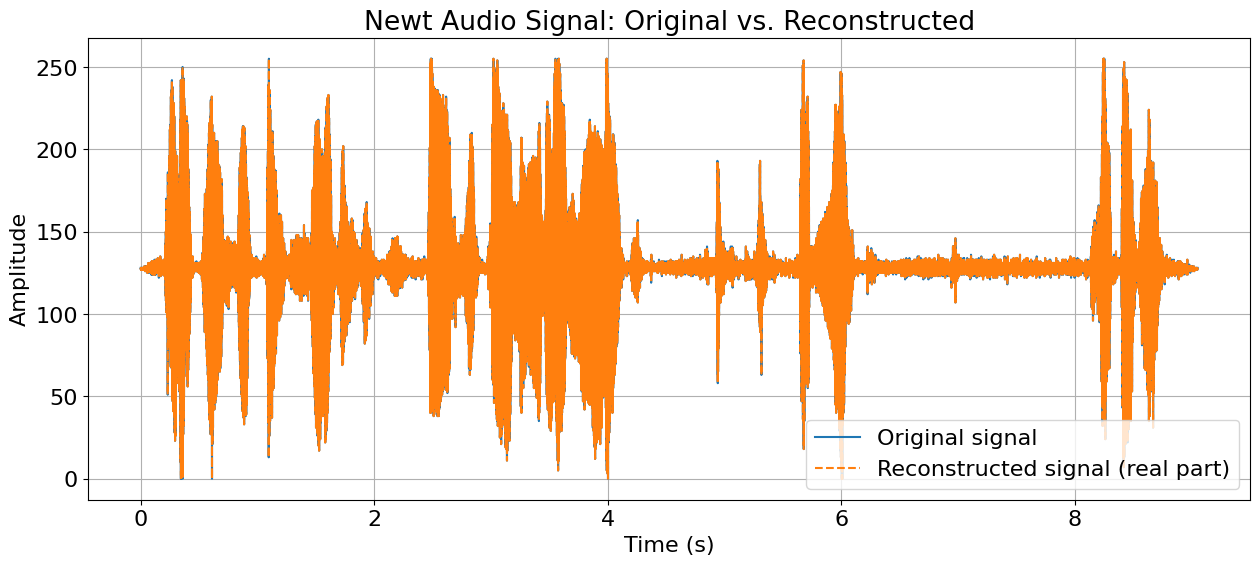

In [46]:
# fft and ifft
y_newt_fft = np.fft.fft(y_newt)
y_newt_recon = np.fft.ifft(y_newt_fft)

# plot
plt.figure(figsize=(15, 6))
plt.plot(t_newt, y_newt, label='Original signal')
plt.plot(t_newt, y_newt_recon.real, '--', label='Reconstructed signal (real part)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Newt Audio Signal: Original vs. Reconstructed')
plt.legend()
plt.grid()
plt.show()

In [47]:
np.corrcoef(abs(y_newt), abs(y_newt_recon))

array([[1., 1.],
       [1., 1.]])

## Compare the original signal with the reconstructed signal by listening

In [48]:
# Original signal
Audio(data=y_newt, rate=sample_rate)

In [49]:
# Digitized signal
Audio(data=abs(y_newt_recon), rate=sample_rate)